In [3]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from config import TRAIN_DIR, TEST_DIR, CLASSES, IMAGE_SIZE, SEED
from dataset import BrainTumorDataset

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [5]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

full_train_dataset = BrainTumorDataset(TRAIN_DIR, CLASSES, transform=transform)
test_dataset = BrainTumorDataset(TEST_DIR, CLASSES, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, len(CLASSES))
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [7]:
model = BaselineCNN().to(device)

model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [9]:
def run_epoch(model, data_loader, criterion, optimizer=None, training=False):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()
        
        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()
        
        total_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [10]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        training=True
    )

    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        criterion,
        training=False
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.7277 | Train Acc: 0.7083 | Val Loss: 0.5300 | Val Acc: 0.7830
Epoch 2/5 | Train Loss: 0.4125 | Train Acc: 0.8473 | Val Loss: 0.3234 | Val Acc: 0.8652
Epoch 3/5 | Train Loss: 0.2662 | Train Acc: 0.8998 | Val Loss: 0.2601 | Val Acc: 0.8964
Epoch 4/5 | Train Loss: 0.1748 | Train Acc: 0.9348 | Val Loss: 0.2328 | Val Acc: 0.9116
Epoch 5/5 | Train Loss: 0.1174 | Train Acc: 0.9569 | Val Loss: 0.2090 | Val Acc: 0.9286


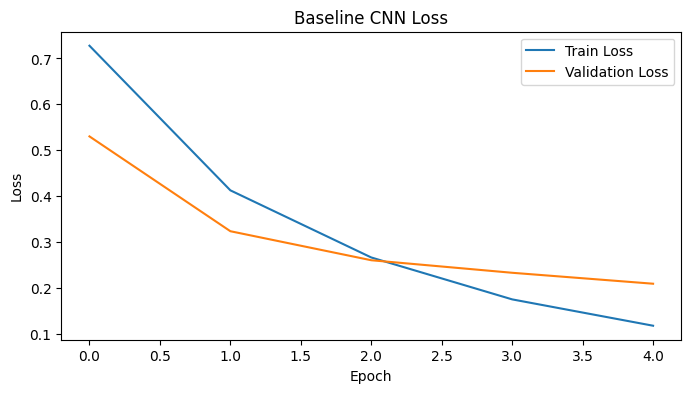

In [11]:
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

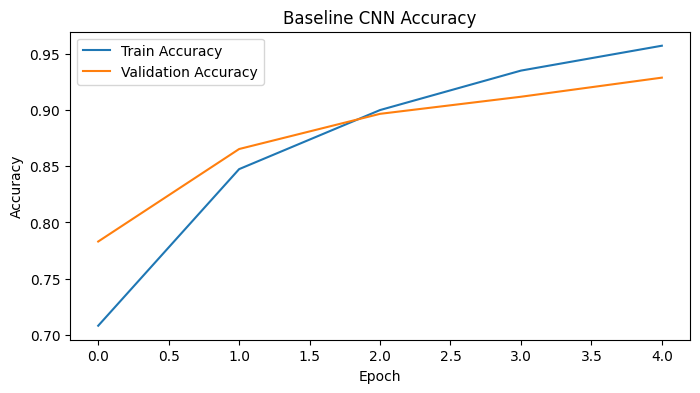

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
best_val_acc = max(history["val_acc"])
best_epoch = history["val_acc"].index(best_val_acc) + 1

best_epoch, best_val_acc

(5, 0.9285714285714286)